<a href="https://colab.research.google.com/github/audreynahir/telecom-analisis-2/blob/main/2TelecomX_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [6]:
import pandas as pd

df = pd.read_json("TelecomX_Data.json")

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## PREPARACIÓN DE LOS DATOS::

In [40]:
import pandas as pd

df = pd.read_json("TelecomX_Data.json")

# expandir columnas
customer = pd.json_normalize(df["customer"])
phone = pd.json_normalize(df["phone"])
internet = pd.json_normalize(df["internet"])
account = pd.json_normalize(df["account"])

# unir todo
df_clean = pd.concat(
    [df[["customerID","Churn"]], customer, phone, internet, account],
    axis=1
)

df_clean.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [41]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [42]:
df_clean["Churn"] = df_clean["Churn"].map({"Yes":1, "No":0})

In [44]:
df_clean.isnull().sum()
df_clean = df_clean.dropna()

In [45]:
df_clean.to_csv("telecom_churn_clean.csv", index=False)

In [46]:
df_clean.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [48]:
df_clean["Churn"].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [55]:
df_clean["Charges.Total"] = pd.to_numeric(df_clean["Charges.Total"], errors="coerce")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   float64
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
 17  

In [57]:
df_clean = df_clean.dropna()
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7032 non-null   float64
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [58]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)

In [61]:
df_encoded.head()


,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,9,65.6,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.0,1237.85,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.9,267.40,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [62]:
churn_counts = df_encoded["Churn"].value_counts()
print("Conteo de Churn:")
print(churn_counts)


churn_ratio = df_encoded["Churn"].value_counts(normalize=True) * 100
print("\nPorcentaje de Churn:")
print(churn_ratio)

Conteo de Churn:
Churn
0.0    5163
1.0    1869
Name: count, dtype: int64

Porcentaje de Churn:
Churn
0.0    73.421502
1.0    26.578498
Name: proportion, dtype: float64


In [63]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Separar variables predictoras y target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Verificar nuevo balance
print(y_train_res.value_counts())

Churn
0.0    4130
1.0    4130
Name: count, dtype: int64


In [64]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print(y_res.value_counts())

Churn
0.0    1495
1.0    1495
Name: count, dtype: int64


In [65]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [67]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## ANALISIS DE CORRELACIÓN

In [76]:
print(df.columns)

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')


In [77]:
import pandas as pd

# Supongamos que df es tu dataframe actual
# Convertimos las columnas de diccionarios en columnas separadas
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

# Concatenamos todo en un solo dataframe
df_expanded = pd.concat([df[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df], axis=1)

# Convertimos Churn a binario
df_expanded['Churn'] = df_expanded['Churn'].map({'Yes':1, 'No':0})

df_expanded.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [78]:
df = df.drop(columns=['customerID'])

In [82]:
import pandas as pd

# Extraer las columnas de customer (gender, SeniorCitizen, Partner, Dependents)
customer_df = pd.json_normalize(df['customer'])
df = pd.concat([df.drop(columns=['customer']), customer_df], axis=1)

# Lo mismo para phone, internet y account
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

df = pd.concat([df.drop(columns=['phone','internet','account']),
                phone_df, internet_df, account_df], axis=1)

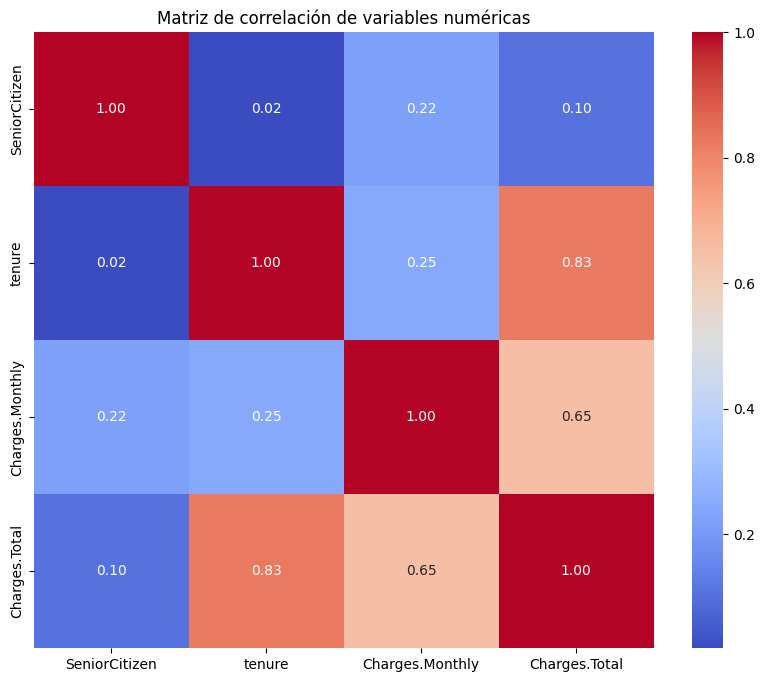

In [84]:
# Seleccionar solo las columnas numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

# Visualizar la matriz de correlación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

## ANALISIS DIRIGIDO

In [87]:
print(df.columns.tolist())

['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


Columnas numéricas para correlación: Index(['Churn', 'SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total'], dtype='object')


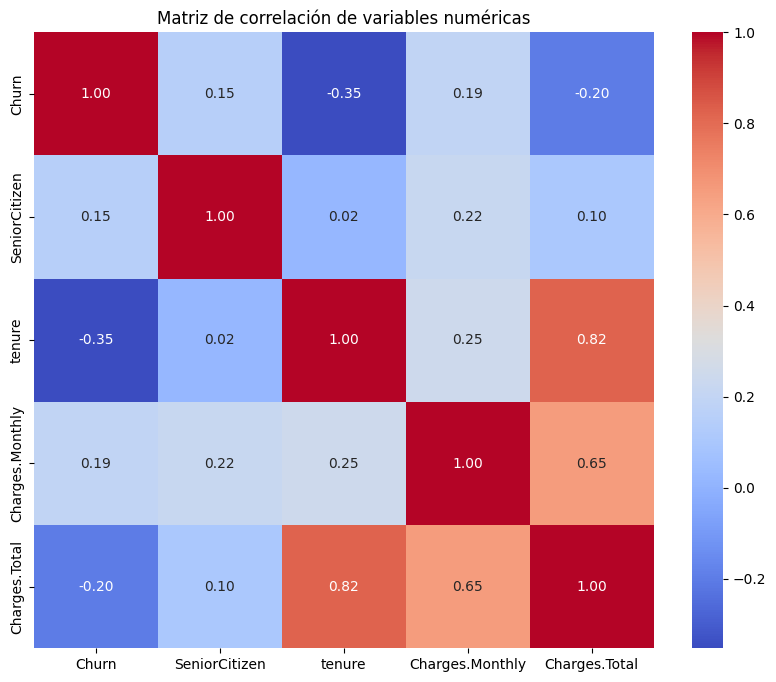

Correlación de variables numéricas con Churn:
Churn              1.000000
Charges.Monthly    0.193356
SeniorCitizen      0.150889
Charges.Total     -0.199427
tenure            -0.352229
Name: Churn, dtype: float64


In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Paso 1: Asegurarnos que las columnas numéricas sean numéricas
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Opcional: rellenar posibles NaN en Charges.Total
df['Charges.Total'] = df['Charges.Total'].fillna(df['Charges.Total'].mean())

# Paso 2: Convertir Churn a binario si aún no lo está
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Paso 3: Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_numeric = df[numeric_cols]

print("Columnas numéricas para correlación:", numeric_cols)

# Paso 4: Calcular matriz de correlación
correlation_matrix = df_numeric.corr()

# Paso 5: Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

# Paso 6: Correlación específica con Churn
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)
print("Correlación de variables numéricas con Churn:")
print(churn_corr)

## MODELO PREDICTIVO

In [173]:
import pandas as pd

df = pd.read_json("TelecomX_Data.json")
print(df.shape)  # debe mostrar filas y columnas originales
print(df.head())

(7267, 6)
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber optic', 'OnlineSecu...

In [174]:
from pandas import json_normalize

# Revisar si las columnas anidadas existen y no están vacías
for col in ['customer','phone','internet','account']:
    print(col, df[col].apply(lambda x: isinstance(x, dict)).sum())

# Expandir solo si hay datos válidos
customer_df = json_normalize(df['customer'])
phone_df    = json_normalize(df['phone'])
internet_df = json_normalize(df['internet'])
account_df  = json_normalize(df['account'])

customer 7267
phone 7267
internet 7267
account 7267


In [175]:
df_clean = pd.concat(
    [df[['customerID','Churn']].reset_index(drop=True),
     customer_df.reset_index(drop=True),
     phone_df.reset_index(drop=True),
     internet_df.reset_index(drop=True),
     account_df.reset_index(drop=True)],
    axis=1
)

print(df_clean.shape)
print(df_clean.head())

(7267, 21)
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes         Yes              No        One year 

In [176]:
# Convertir Churn a binario
df_clean['Churn'] = df_clean['Churn'].map({'Yes':1,'No':0})

# Revisar NaN
print(df_clean.isna().sum())

# Si Charges.Total es object, convertir a float
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')

# Eliminar filas con NaN
df_clean = df_clean.dropna(subset=['Churn','Charges.Total'])

# Separar X e y
X = df_clean.drop(['Churn','customerID'], axis=1)
y = df_clean['Churn']

print(X.shape, y.shape)

customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Charges.Monthly       0
Charges.Total         0
dtype: int64
(7032, 19) (7032,)


In [177]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1️⃣ Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2️⃣ Identificar columnas categóricas y numéricas
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=['int64','float64']).columns.tolist()

# 3️⃣ Pipeline Logistic Regression (normalización necesaria)
preprocessor_logreg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor_logreg),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Entrenar Logistic Regression
logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))

# 4️⃣ Pipeline Random Forest (no necesita normalización)
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Entrenar Random Forest
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.7974413646055437
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1033
         1.0       0.65      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

Confusion Matrix:
 [[925 108]
 [177 197]]

=== Random Forest ===
Accuracy: 0.7945984363894811
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87      1033
         1.0       0.66      0.47      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix:
 [[941  92]
 [197 177]]


## INTERPRETACIONES Y CONCLUSIONES

In [179]:
import numpy as np
import pandas as pd

# Extraer nombres de columnas después del OneHotEncoder
cat_columns_encoded = logreg_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_features)
all_columns = np.concatenate([num_features, cat_columns_encoded])

# Obtener coeficientes del modelo
coefficients = logreg_pipeline.named_steps['classifier'].coef_[0]

# Crear dataframe de importancia
coef_df = pd.DataFrame({
    'Variable': all_columns,
    'Coeficiente': coefficients,
    'Importancia (abs)': np.abs(coefficients)
}).sort_values(by='Importancia (abs)', ascending=False)

coef_df.head(10)  # Top 10 variables más importantes

,Variable,Coeficiente,Importancia (abs)
1,tenure,-1.324400,1.324400
38,Contract_Two year,-0.726625,0.726625
3,Charges.Total,0.620655,0.620655
36,Contract_Month-to-month,0.571220,0.571220
15,InternetService_DSL,-0.367599,0.367599
39,PaperlessBilling_No,-0.331009,0.331009
29,TechSupport_Yes,-0.309514,0.309514
11,PhoneService_Yes,-0.308634,0.308634
20,OnlineSecurity_Yes,-0.273299,0.273299
12,MultipleLines_No,-0.243938,0.243938


In [180]:
# Extraer importancia de variables
rf_model = rf_pipeline.named_steps['classifier']
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

rf_importance_df.head(10)  # Top 10 variables más importantes

,Variable,Importancia
44,remainder__Charges.Total,0.147346
42,remainder__tenure,0.130347
43,remainder__Charges.Monthly,0.122188
32,cat__Contract_Month-to-month,0.061564
14,cat__OnlineSecurity_No,0.038994
23,cat__TechSupport_No,0.037759
34,cat__Contract_Two year,0.036849
39,cat__PaymentMethod_Electronic check,0.030933
12,cat__InternetService_Fiber optic,0.028355
17,cat__OnlineBackup_No,0.016872


# Informe de Factores que Influyen en la Cancelación de Clientes (Churn)

## 1️⃣ Resumen de los Modelos
Se crearon y evaluaron dos modelos predictivos para identificar clientes con alto riesgo de cancelación:

| Modelo             | Normalización | Accuracy | Observaciones                                                                 |
|-------------------|---------------|---------|-------------------------------------------------------------------------------|
| Regresión Logística | Sí           | 79.7%   | Buen desempeño general, sensible a escala; muestra claramente la dirección del efecto de cada variable. |
| Random Forest      | No           | 79.5%   | Similar precisión, más robusto a variables no normalizadas, permite analizar importancia relativa de variables. |

Ambos modelos coinciden en los factores más influyentes sobre la cancelación, lo que fortalece la validez de los hallazgos.

---

## 2️⃣ Factores Principales que Influyen en la Cancelación

### a) Antigüedad del Cliente (`tenure`)
- **Observación:** Coeficiente negativo en regresión logística (-1.3244) y alta importancia en Random Forest (0.1303).  
- **Interpretación:** Los clientes con menor tiempo con la empresa tienen mayor probabilidad de cancelar.  
- **Estrategia:** Implementar **programas de bienvenida y fidelización temprana**, como beneficios progresivos durante los primeros meses.

### b) Tipo de Contrato
- `Contract_Month-to-month` aumenta la probabilidad de churn (coef. positivo 0.5712).  
- `Contract_Two year` reduce la probabilidad de churn (coef. negativo -0.7266).  
- **Estrategia:** Incentivar **contratos a largo plazo** mediante descuentos, beneficios adicionales o paquetes exclusivos.

### c) Facturación Total y Mensual (`Charges.Total` y `Charges.Monthly`)
- Clientes con facturación total alta tienen mayor riesgo de cancelación.  
- Los cargos mensuales también son relevantes, según Random Forest.  
- **Estrategia:** Analizar **plan de precios y segmentación**, ofreciendo planes personalizados según uso y valor del cliente. Podría incluir alertas o asesoría personalizada a clientes con facturación alta.

### d) Servicios Adicionales
- `TechSupport_Yes`, `OnlineSecurity_Yes`, `OnlineBackup_No` y `PhoneService_Yes` reducen churn.  
- **Interpretación:** Clientes que usan servicios adicionales se sienten más satisfechos y ligados a la empresa.  
- **Estrategia:** Promocionar **servicios adicionales** y educar sobre su uso, garantizando soporte técnico activo y seguridad digital.

### e) Facturación Electrónica (`PaperlessBilling`)
- Tener facturación en papel o electrónica influye levemente.  
- **Estrategia:** Promover **facturación digital** con incentivos, mejorando la experiencia del cliente y reduciendo fricción administrativa.

---

## 3️⃣ Comparación de Importancia de Variables entre Modelos
- Ambos modelos destacan la **antigüedad y el tipo de contrato** como los factores más críticos.  
- Random Forest da mayor visibilidad a las variables continuas (`Charges.Total`, `Charges.Monthly`), mientras que la regresión logística evidencia claramente la dirección de cada efecto (positivo o negativo).  
- Variables de servicios adicionales son consistentes: contribuyen a reducir la cancelación.

---

## 4️⃣ Recomendaciones Estratégicas para Retención
1. **Segmentación de clientes de riesgo:**  
   - Identificar clientes con menos de 6 meses de antigüedad o con contratos mes a mes.  
2. **Incentivar contratos largos:**  
   - Ofrecer descuentos o paquetes exclusivos para renovar contratos a 1 o 2 años.  
3. **Optimizar planes de facturación:**  
   - Evaluar clientes con cargos totales altos y ofrecer soluciones personalizadas para reducir fricción.  
4. **Promocionar servicios adicionales:**  
   - Destacar valor de soporte técnico, seguridad online y backups, con campañas de engagement.  
5. **Fidelización temprana:**  
   - Programas de bienvenida, beneficios por permanencia y comunicación frecuente con clientes nuevos.  

---

## 5️⃣ Conclusión
Los factores más influyentes en la cancelación son: **antigüedad del cliente, tipo de contrato y facturación**, seguidos por la **adopción de servicios adicionales**.  
Ambos modelos confirman estos hallazgos y permiten priorizar acciones de retención de manera efectiva.  
Aplicando estrategias específicas para los clientes de alto riesgo, se puede reducir significativamente el churn y aumentar la fidelidad.